=== APERÇU DU FICHIER ===


,competition_id,selling_season,selling_period,competitor_id,price_competitor,price,demand,competitor_has_capacity,calculation_duration,errors
0,48PU5k,1,1,DelicateMoose,80.0,37.0,4,True,0.0,NaN
1,48PU5k,1,2,DelicateMoose,37.0,44.4,0,True,0.0,NaN
2,48PU5k,1,3,DelicateMoose,36.5,53.3,0,True,0.0,NaN
3,48PU5k,1,4,DelicateMoose,36.1,61.5,0,True,0.0,NaN
4,48PU5k,1,5,DelicateMoose,36.1,67.2,0,True,0.0,NaN


(20000, 10)

Colonnes : ['competition_id', 'selling_season', 'selling_period', 'competitor_id', 'price_competitor', 'price', 'demand', 'competitor_has_capacity', 'calculation_duration', 'errors']

=== APRES HARMONISATION ===


,competition_id,selling_season,day,competitor_id,competitor_price,our_price,our_demand,competitor_has_capacity,calculation_duration,errors,revenue,cum_revenue
0,48PU5k,1,1,DelicateMoose,80.0,37.0,4,True,0.0,NaN,148.0,148.0
1,48PU5k,1,2,DelicateMoose,37.0,44.4,0,True,0.0,NaN,0.0,148.0
2,48PU5k,1,3,DelicateMoose,36.5,53.3,0,True,0.0,NaN,0.0,148.0
3,48PU5k,1,4,DelicateMoose,36.1,61.5,0,True,0.0,NaN,0.0,148.0
4,48PU5k,1,5,DelicateMoose,36.1,67.2,0,True,0.0,NaN,0.0,148.0



=== KPIs PAR SAISON ===


C:\Users\louiz\AppData\Local\Temp\ipykernel_8432\2646817155.py:49: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x["our_price"].corr(x["our_demand"])).reset_index(drop=True)
C:\Users\louiz\AppData\Local\Temp\ipykernel_8432\2646817155.py:52: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x["competitor_price"].corr(x["our_demand"])).reset_index(drop=True)


,competition_id,selling_season,our_price,competitor_price,our_demand,revenue,price_demand_corr,comp_demand_corr
0,48PU5k,1,68.767,60.176,80,4694.8,-0.516091,0.022404
1,48PU5k,2,66.878,63.008,80,4888.5,-0.364339,-0.047182
2,48PU5k,3,66.892,62.469,80,5022.0,-0.249801,0.025937
3,48PU5k,4,39.322,27.681,80,1661.4,-0.395390,-0.116715
4,48PU5k,5,51.585,41.393,80,2946.2,-0.385578,-0.079253


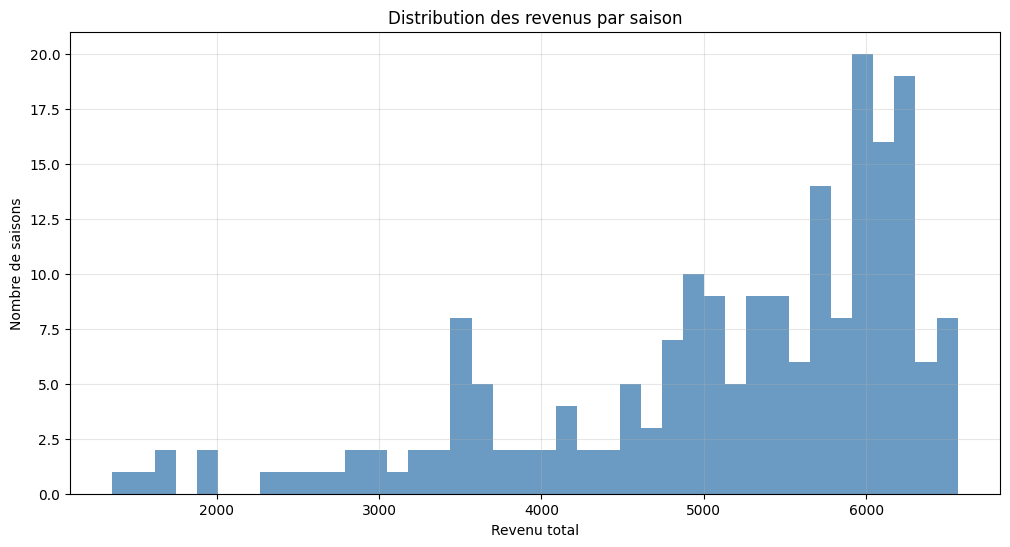


=== BOOKING CURVE MOYENNE (30 / 100 jours) ===


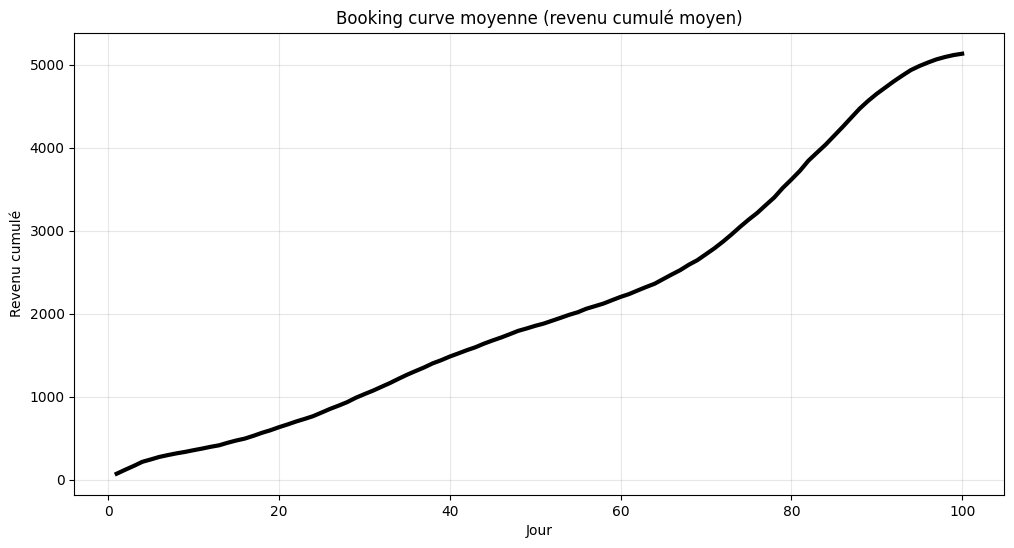


=== SAISON TYPIQUE (revenu ≈ 5485.6) ===


,competition_id,selling_season,day,competitor_id,competitor_price,our_price,our_demand,competitor_has_capacity,calculation_duration,errors,revenue,cum_revenue
7100,48PU5k,72,1,DelicateMoose,80.0,57.0,1,True,0.0,NaN,57.0,57.0
7101,48PU5k,72,2,DelicateMoose,57.0,61.2,1,True,0.0,NaN,61.2,118.2
7102,48PU5k,72,3,DelicateMoose,61.2,65.3,0,True,0.0,NaN,0.0,118.2
7103,48PU5k,72,4,DelicateMoose,59.7,67.1,1,True,0.0,NaN,67.1,185.3
7104,48PU5k,72,5,DelicateMoose,58.2,70.1,0,True,0.0,NaN,0.0,185.3


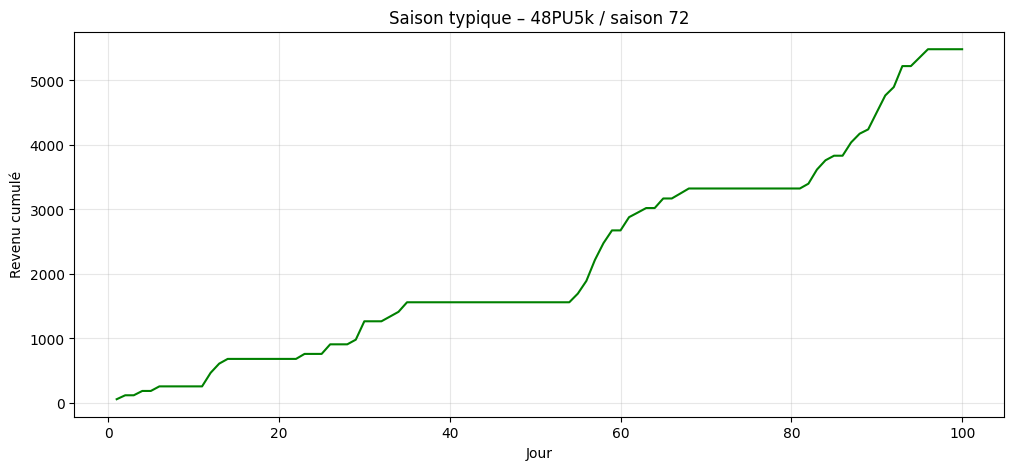

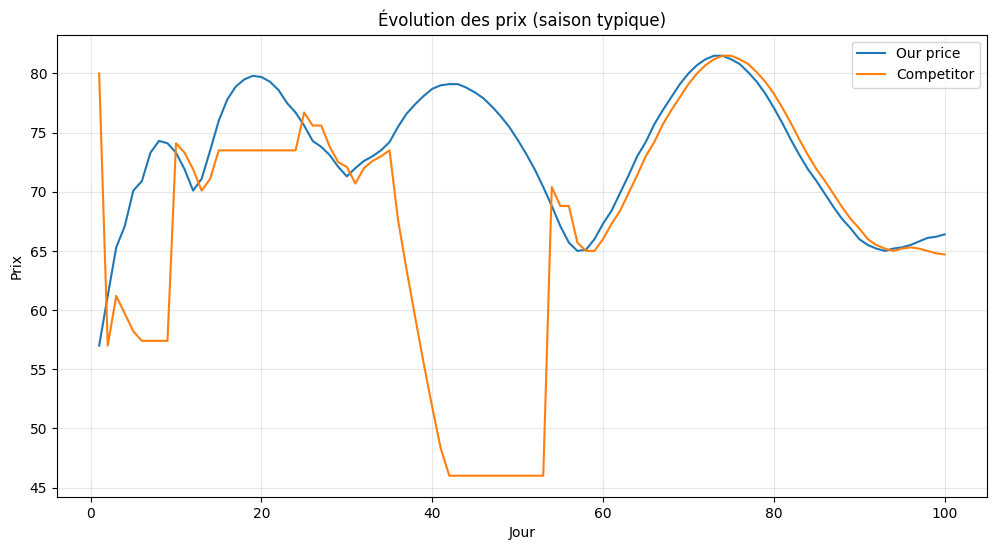

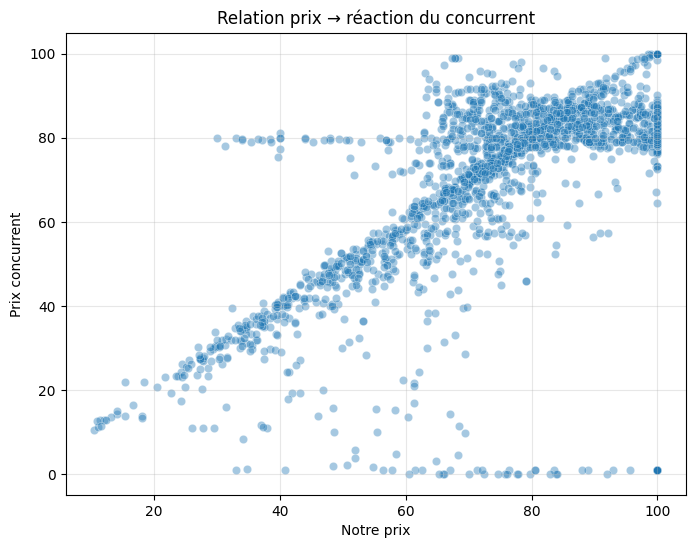


=== MODELE GLOBAL (dépendance de la demande) ===
β0 = 1.9840
β1 (our price) = -0.0342
β2 (competitor price) = 0.0193


In [3]:

# ANALYSE COMPLETE D’UN FICHIER DPC


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


csv_path = "duopoly_competition_details.csv"  
df = pd.read_csv(csv_path)

print("=== APERÇU DU FICHIER ===")
display(df.head())
print(df.shape)
print("\nColonnes :", list(df.columns))

rename_map = {
    "price": "our_price",
    "price_competitor": "competitor_price",
    "demand": "our_demand",
    "selling_period": "day"
}

df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})

# Si le revenu n'existe pas → le créer
if "revenue" not in df.columns:
    df["revenue"] = df["our_price"] * df["our_demand"]

# Revenu cumulé par saison
df["cum_revenue"] = df.groupby(["competition_id", "selling_season"])["revenue"].cumsum()

print("\n=== APRES HARMONISATION ===")
display(df.head())

#  KPIs par saison

print("\n=== KPIs PAR SAISON ===")

season_kpis = df.groupby(["competition_id", "selling_season"]).agg({
    "our_price": "mean",
    "competitor_price": "mean",
    "our_demand": "sum",
    "revenue": "sum"
}).reset_index()

season_kpis["price_demand_corr"] = df.groupby(["competition_id", "selling_season"]) \
    .apply(lambda x: x["our_price"].corr(x["our_demand"])).reset_index(drop=True)

season_kpis["comp_demand_corr"] = df.groupby(["competition_id", "selling_season"]) \
    .apply(lambda x: x["competitor_price"].corr(x["our_demand"])).reset_index(drop=True)

display(season_kpis.head())

# Distribution des revenus
plt.figure(figsize=(12,6))
plt.hist(season_kpis["revenue"], bins=40, color="steelblue", alpha=0.8)
plt.title("Distribution des revenus par saison")
plt.xlabel("Revenu total")
plt.ylabel("Nombre de saisons")
plt.grid(alpha=0.3)
plt.show()

# Booking curve – moyenne sur toutes saisons
print("\n=== BOOKING CURVE MOYENNE (30 / 100 jours) ===")

plt.figure(figsize=(12,6))

all_cum = []

for (_, _), sdf in df.groupby(["competition_id", "selling_season"]):
    c = sdf.groupby("day")["revenue"].sum().cumsum().values
    all_cum.append(c)

avg_curve = np.mean(all_cum, axis=0)

plt.plot(range(1, len(avg_curve)+1), avg_curve, color="black", linewidth=3)
plt.title("Booking curve moyenne (revenu cumulé moyen)")
plt.xlabel("Jour")
plt.ylabel("Revenu cumulé")
plt.grid(alpha=0.3)
plt.show()

# Exemple : 1 saison typique (médiane du revenu)
mid_season_rev = season_kpis["revenue"].median()
mid_season_id = season_kpis.iloc[(season_kpis["revenue"] - mid_season_rev).abs().argmin()]

cid = mid_season_id["competition_id"]
sid = mid_season_id["selling_season"]

example = df[(df["competition_id"] == cid) & (df["selling_season"] == sid)]

print(f"\n=== SAISON TYPIQUE (revenu ≈ {mid_season_rev:.1f}) ===")
display(example.head())

plt.figure(figsize=(12,5))
plt.plot(example["day"], example["cum_revenue"], label="cum revenue", color="green")
plt.title(f"Saison typique – {cid} / saison {sid}")
plt.xlabel("Jour")
plt.ylabel("Revenu cumulé")
plt.grid(alpha=0.3)
plt.show()


# nalyse prix – stratégie interne
plt.figure(figsize=(12,6))
plt.plot(example["day"], example["our_price"], label="Our price")
plt.plot(example["day"], example["competitor_price"], label="Competitor")
plt.title("Évolution des prix (saison typique)")
plt.xlabel("Jour")
plt.ylabel("Prix")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Réaction du concurrent (scatter)
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df.sample(min(2000, len(df))), 
    x="our_price", 
    y="competitor_price", 
    alpha=0.4
)
plt.title("Relation prix → réaction du concurrent")
plt.xlabel("Notre prix")
plt.ylabel("Prix concurrent")
plt.grid(alpha=0.3)
plt.show()

# Élasticité empirique (régression rapide)
# 
from sklearn.linear_model import LinearRegression

df_clean = df.dropna(subset=["our_price", "competitor_price", "our_demand"])
X = df_clean[["our_price", "competitor_price"]]
y = df_clean["our_demand"]

model = LinearRegression().fit(X,y)

print("\n=== MODELE GLOBAL (dépendance de la demande) ===")
print(f"β0 = {model.intercept_:.4f}")
print(f"β1 (our price) = {model.coef_[0]:.4f}")
print(f"β2 (competitor price) = {model.coef_[1]:.4f}")




